In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/train.csv")
df=pd.DataFrame(data)
print(df.isnull().sum())
print(df.head())
print(df["meal_id"].nunique())
print(df["center_id"].nunique())

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0  

In [3]:
df["discount"] = (df["base_price"] - df["checkout_price"])/df["base_price"]
df = pd.get_dummies(df, columns=["meal_id","center_id"])
df["promo_discount"] =df["discount"] * df["homepage_featured"]*df["emailer_for_promotion"]
X=df.drop(["num_orders","id"],axis=1)
Y=df["num_orders"]
print(X.shape)

(456548, 135)


In [4]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
model=RandomForestRegressor()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
print(mean_squared_error(Y_test,Y_pred))
print(r2_score(Y_train, model.predict(X_train)))
print(r2_score(Y_test, Y_pred))

25475.101349429417
0.9772914887213747
0.83298681314328


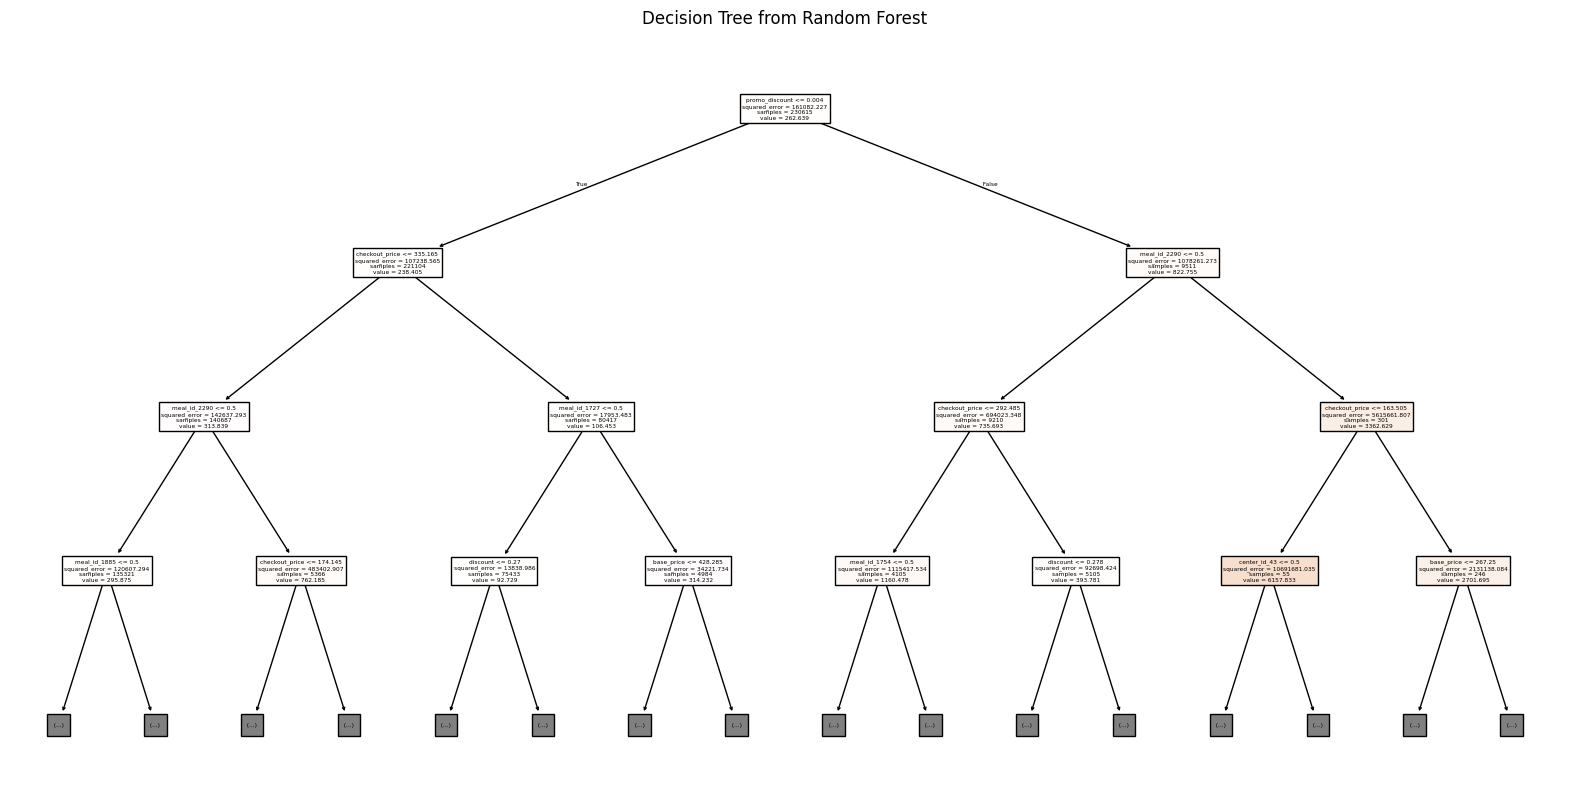

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot,feature_names=X.columns,max_depth=3,filled=True)
plt.title("Decision Tree from Random Forest")
plt.show()

In [6]:
importance = pd.DataFrame({"feature": X.columns,"importance": model.feature_importances_})

print(importance.sort_values("importance",ascending=False).head(20))

                   feature  importance
1           checkout_price    0.173382
134         promo_discount    0.081106
36            meal_id_2290    0.080093
5                 discount    0.063680
0                     week    0.061795
2               base_price    0.060160
75            center_id_43    0.037311
4        homepage_featured    0.037181
28            meal_id_1885    0.028688
59            center_id_13    0.027921
22            meal_id_1754    0.019565
3    emailer_for_promotion    0.017165
31            meal_id_1971    0.016222
7             meal_id_1109    0.015219
32            meal_id_1993    0.015128
21            meal_id_1727    0.014715
120          center_id_137    0.013029
57            center_id_10    0.012907
52            meal_id_2707    0.011764
54            meal_id_2826    0.011034
